# AGX Benchmark Analysis

This notebook analyzes TinyML benchmark results for AGX platforms, focusing on:
1. **Data Reading and Preprocessing**: Load and standardize CSV data
2. **Success Rate Plotting**: Visualize model success rates across stages
3. **Model Cost/Time Plotting**: Compare execution time and operational costs

## 1. Data Reading and Preprocessing

Load CSV files, standardize columns, and compute derived metrics for analysis.

### 1.1 Load and Standardize Data

In [7]:
from pathlib import Path
import pandas as pd
import numpy as np

# Resolve data directory (works from repo root or notebook folder)
DATA_DIR = Path().resolve()
 

# Canonical labels and ordering (single source of truth)
MODEL_LABELS = {
    "gpt-5": "G5",
    "gpt-4o": "G4o",
    "gpt-4o-mini": "G4o-m",
    "phi4": "Phi4",
    "qwen32": "Qw32B",
    "qwen14": "Qw14B",
    "codestral": "Co22B",
    "gemma3": "Ge3",
}
PROCESSOR_LABELS = { "dp": "DP",
                    "mc": "MC",  
                    "sg": "SG",
                    "psg": "PSG", 
                    "tpusg": "TPUSG"}

MODEL_ORDER_PREF = list(MODEL_LABELS.keys())


PROCESSOR_ORDER_PREF = list(PROCESSOR_LABELS.keys())

 
# Load single consolidated CSV file
csv_path = DATA_DIR / "all-agx.csv"
if not csv_path.exists():
    raise FileNotFoundError(f"File not found: {csv_path}")

# Read and preprocess data
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

# Check for required columns
required_cols = {"status", "latency", "processor", "model"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"CSV is missing required columns: {sorted(missing)}")

# Standardize and clean data
df = df.copy()
df["status"] = df["status"].astype(str).str.strip().str.lower()
df["status_group"] = np.where(df["status"] == "success", "success", "failure")
df["processor_std"] = df["processor"].astype(str).str.strip().str.lower()
df["model_std"] = df["model"].astype(str).str.strip().str.lower()

# Add total_cost if not present
if "total_cost" not in df.columns:
    df["total_cost"] = np.nan

print(f"Loaded data from: {csv_path.name}")
print(f"Total rows: {len(df)}")
print(f"Columns: {list(df.columns)}")


Loaded data from: all-agx.csv
Total rows: 300
Columns: ['name', 'trace_id', 'batch_id', 'status', 'latency', 'total_tokens', 'prompt_tokens', 'completion_tokens', 'total_cost', 'prompt_cost', 'completion_cost', 'parameters', 'processor', 'model', 'status_group', 'processor_std', 'model_std']


### 1.2 Compute Derived Metrics

In [14]:
import pprint

# ═══════════════════════════════════════════════════════════════════════════
# STEP 1: Determine model and processor order
# ═══════════════════════════════════════════════════════════════════════════
models_present = list(df["model_std"].unique())
processors_present = list(df["processor_std"].unique())

model_order = [m for m in MODEL_ORDER_PREF if m in models_present] + [
    m for m in models_present if m not in MODEL_ORDER_PREF
]
processor_order = [p for p in PROCESSOR_ORDER_PREF if p in processors_present] + [
    p for p in processors_present if p not in PROCESSOR_ORDER_PREF
]

# ═══════════════════════════════════════════════════════════════════════════
# STEP 2: Calculate success rates
# ═══════════════════════════════════════════════════════════════════════════
pivot_data = (
    df.groupby(["model_std", "processor_std", "status_group"])
    .size()
    .unstack(fill_value=0)
)

for missing_col in ("success", "failure"):
    if missing_col not in pivot_data.columns:
        pivot_data[missing_col] = 0

success_rate_dict = {}
for (model, processor), row in pivot_data.iterrows():
    success_count = int(row.get("success", 0))
    failure_count = int(row.get("failure", 0))
    total = success_count + failure_count
    success_rate = success_count / total if total else 0.0

    exp_success_rate = 0.0
    if total and "generation_count" in df.columns:
        success_rows = df[
            (df["model_std"] == model)
            & (df["processor_std"] == processor)
            & (df["status_group"] == "success")
        ]
        if not success_rows.empty:
            exp_success_rate = (
                np.exp(-0.5 * (success_rows["generation_count"].astype(float) - 1))
                .sum()
                / total
            )

    success_rate_dict[(model, processor)] = {
        "success_count": success_count,
        "failure_count": failure_count,
        "total": total,
        "success_rate": success_rate,
        "exp_success_rate": exp_success_rate,
    }

print("Success rate summary (fraction):")
pprint.pprint(success_rate_dict)

# ═══════════════════════════════════════════════════════════════════════════
# STEP 3: Aggregate latency metrics by model
# ═══════════════════════════════════════════════════════════════════════════
def _agg_mean(frame: pd.DataFrame, metric: str):
    """Aggregate mean of a metric grouped by processor."""
    if frame.empty or metric not in frame:
        return {p: 0.0 for p in processor_order}
    return (
        frame.groupby("processor_std")[metric]
        .mean()
        .reindex(processor_order)
        .fillna(0.0)
        .to_dict()
    )


def build_model_dict(model_key: str):
    """Build latency statistics for a given model."""
    subset = df[df["model_std"] == model_key]
    if subset.empty:
        return {"latency": {}}

    df_pass = subset[subset["status_group"] == "success"]
    df_fail = subset[subset["status_group"] != "success"]

    pass_latency = _agg_mean(df_pass, "latency")
    fail_latency = _agg_mean(df_fail, "latency")

    def safe_mean(frame, metric):
        if frame.empty or frame[metric].dropna().empty:
            return 0.0
        return float(frame[metric].mean())

    return {
        "latency": {
            **pass_latency,
            "total": safe_mean(df_pass, "latency"),
            "total_x": safe_mean(df_fail, "latency"),
        }
    }

# ═══════════════════════════════════════════════════════════════════════════
# STEP 4: Select GPT models for comparison and build their statistics
# ═══════════════════════════════════════════════════════════════════════════
models_by_volume = df["model_std"].value_counts().index.tolist()
gpt_models = [m for m in models_by_volume if "gpt" in m.lower()]

if gpt_models:
    primary_model = gpt_models[0]
    secondary_model = gpt_models[1] if len(gpt_models) > 1 else None

    primary_stats = build_model_dict(primary_model)
    secondary_stats = build_model_dict(secondary_model) if secondary_model else None

    print("\n" + "=" * 80)
    print("Primary model:", MODEL_LABELS.get(primary_model, primary_model))
    print("=" * 80)
    pprint.pprint(primary_stats)
    if secondary_stats:
        print("\n" + "=" * 80)
        print("Secondary model:", MODEL_LABELS.get(secondary_model, secondary_model))
        print("=" * 80)
        pprint.pprint(secondary_stats)
else:
    primary_model = None
    secondary_model = None
    primary_stats = None
    secondary_stats = None
    print("\nNo GPT models found in the data. Skipping GPT-specific execution time comparison.")


Success rate summary (fraction):
{('qwen32', 'dp'): {'exp_success_rate': 0.0,
                    'failure_count': 14,
                    'success_count': 46,
                    'success_rate': 0.7666666666666667,
                    'total': 60},
 ('qwen32', 'mc'): {'exp_success_rate': 0.0,
                    'failure_count': 4,
                    'success_count': 56,
                    'success_rate': 0.9333333333333333,
                    'total': 60},
 ('qwen32', 'psg'): {'exp_success_rate': 0.0,
                     'failure_count': 3,
                     'success_count': 57,
                     'success_rate': 0.95,
                     'total': 60},
 ('qwen32', 'sg'): {'exp_success_rate': 0.0,
                    'failure_count': 60,
                    'success_count': 0,
                    'success_rate': 0.0,
                    'total': 60},
 ('qwen32', 'tpusg'): {'exp_success_rate': 0.0,
                       'failure_count': 7,
                       'success_cou

## 2. Success Rate Plotting

Visualize success rates for each model across different processor stages using a heatmap with progress bars.

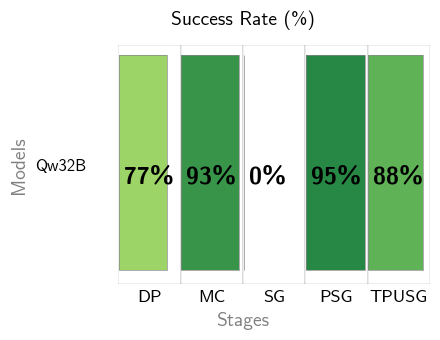

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams["font.family"] = "CMU Sans Serif"

# Build dataframe again to stay in sync even if previous cell is skipped
heatmap_df = pd.DataFrame(
    [
        {
            "model": MODEL_LABELS.get(model, model),
            "processor": processor,
            "success_rate": (data["success_rate"] * 100)
            if data["success_rate"] <= 1
            else data["success_rate"],
        }
        for (model, processor), data in success_rate_dict.items()
    ],
)

heatmap_df = heatmap_df.pivot(index="model", columns="processor", values="success_rate")
heatmap_df = heatmap_df.reindex(
    index=[MODEL_LABELS.get(m, m) for m in model_order],
    columns=processor_order,
)

fig, ax = plt.subplots(figsize=(4.5, 3.5))

cmap = LinearSegmentedColormap.from_list(
    "custom",
    [
        "#D73027",
        "#F65D5F",
        "#F46D43",
        "#FDAE61",
        "#FEE08B",
        "#D9EF8B",
        "#A6D96A",
        "#68BA59",
        "#006837",
    ],
    N=256,
)

ax.set_xlim(0, len(heatmap_df.columns))
ax.set_ylim(0, len(heatmap_df.index))
ax.invert_yaxis()

bar_height_ratio = 0.9

gap = 0

for i, model in enumerate(heatmap_df.index):
    for j, processor in enumerate(heatmap_df.columns):
        value = heatmap_df.loc[model, processor]
        if pd.notna(value):
            bg_rect = mpatches.Rectangle(
                (j + gap / 2, i + gap / 2),
                1 - gap,
                1 - gap,
                facecolor="white",
                edgecolor="black",
                linewidth=0.1,
            )
            ax.add_patch(bg_rect)

            bar_color = cmap(value / 100)
            bar_height = bar_height_ratio
            y_offset = (1 - bar_height) / 2 - 0.01
            x_offset = 0.01
            bar_width = value / 100

            bar_rect = mpatches.Rectangle(
                (j + x_offset, i + y_offset),
                bar_width,
                bar_height,
                facecolor=bar_color,
                edgecolor="none",
                linewidth=0,
            )
            ax.add_patch(bar_rect)

            bar_border = mpatches.Rectangle(
                (j + x_offset, i + y_offset),
                bar_width,
                bar_height,
                facecolor="none",
                edgecolor="#888888",
                linewidth=0.5,
            )
            ax.add_patch(bar_border)

            ax.text(
                j + 0.09,
                i + 0.55,
                f"{value:.0f}%",
                ha="left",
                va="center",
                fontsize=17,
                weight="bold",
                color="black",
                fontname="CMU Sans Serif",
            )

ax.set_xticks([i + 0.5 for i in range(len(heatmap_df.columns))])
ax.set_yticks([i + 0.5 for i in range(len(heatmap_df.index))])
ax.set_xticklabels(
    [PROCESSOR_LABELS.get(col, col).upper() for col in heatmap_df.columns],
    fontsize=13,
    weight="regular",
)
ax.set_yticklabels(heatmap_df.index, fontsize=12, ha="left")

ax.tick_params(axis="both", which="both", length=0)
ax.tick_params(axis="y", pad=60)

ax.set_xlabel("Stages", fontsize=14, weight="regular", labelpad=5, color="gray", x=0.4)
ax.set_ylabel("Models", fontsize=14, weight="regular", labelpad=5, color="gray")

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title("Success Rate (%)", fontsize=14, weight="regular", color="black", pad=15, x=0.4)

plt.tight_layout()
plt.savefig("figs/success-rate_MPU.pdf", dpi=300, bbox_inches="tight")
plt.show()


## 2.5. Exp Success Rate Plotting


webf NOT subset; don't know how to subset; dropped
webf NOT subset; don't know how to subset; dropped


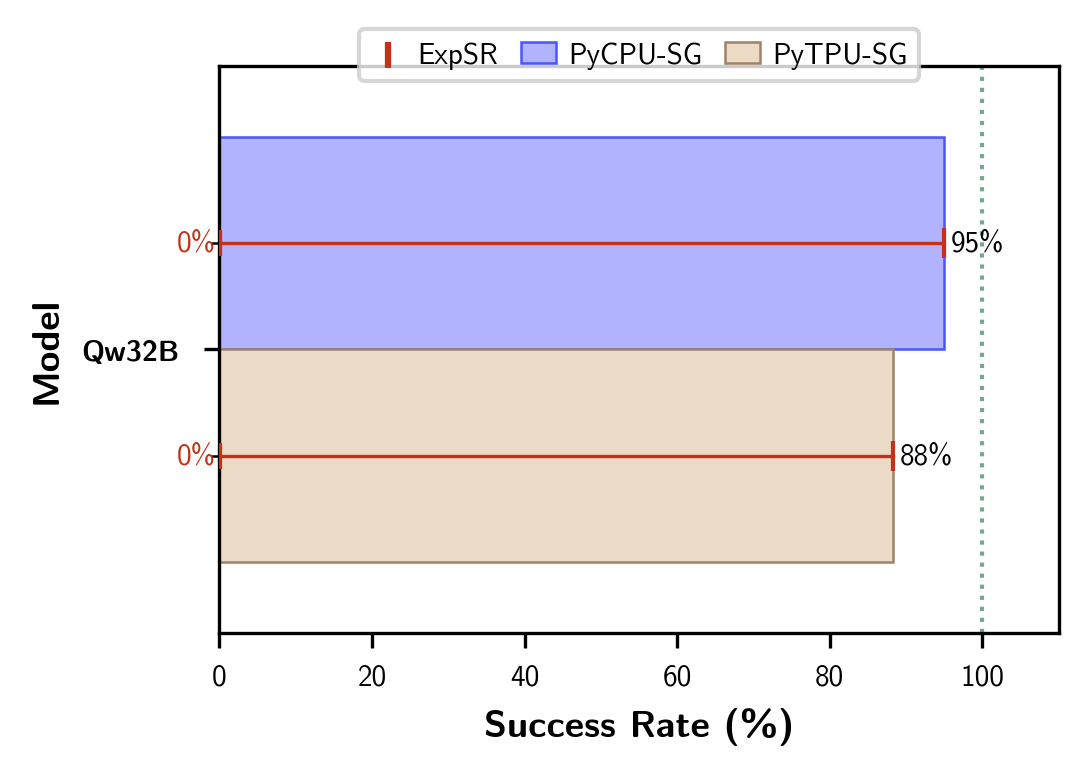

In [10]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# ── Elsevier column widths ────────────────────────────────────────────────────
SINGLE_COL = 3.54   # 90 mm
DOUBLE_COL = 7.48   # 190 mm
# Use SINGLE_COL for a 1-column figure, DOUBLE_COL to span both columns

# ── rcParams for Elsevier ─────────────────────────────────────────────────────
mpl.rcParams.update({
    "font.family":       "CMU Sans Serif",
    "font.size":         8,
    "axes.labelsize":    9,
    "axes.titlesize":    9,
    "xtick.labelsize":   7,
    "ytick.labelsize":   7,
    "legend.fontsize":   7,
    "figure.dpi":        300,
    "savefig.dpi":       300,
    "pdf.fonttype":      42,   # embeds fonts properly in PDF
    "ps.fonttype":       42,
})

# ── Font sizes (explicit overrides if needed) ─────────────────────────────────
FS_LABEL      = 9    # axis labels
FS_TICK       = 7    # y-tick model labels
FS_ANNOTATION = 7    # bar value annotations and ExpSR labels
FS_LEGEND     = 7    # legend text
FS_AXIS_Y     = 9    # y-axis label

# ── Controls ──────────────────────────────────────────────────────────────────
annotate_bars = True

# Prototype: clustered model/task success-rate bars with ExpSR markers
task_map = {'psg': 'PyCPU-SG', 'tpusg': 'PyTPU-SG'}
plot_rows = [
    {
        'model': MODEL_LABELS.get(model, model),
        'processor': processor,
        'task': task_map.get(processor, processor),
        'success_rate': data['success_rate'] * 100,
        'exp_success_rate': data['exp_success_rate'] * 100,
    }
    for (model, processor), data in success_rate_dict.items()
    if processor in task_map
]
plot_df = pd.DataFrame(plot_rows)

if plot_df.empty:
    raise ValueError('No PyCPU-SG / PyTPU-SG rows found for this prototype plot.')

plot_model_labels = set(plot_df['model'].unique())
model_labels = [
    MODEL_LABELS.get(m, m)
    for m in model_order
    if MODEL_LABELS.get(m, m) in plot_model_labels
]
model_positions = np.arange(len(model_labels))[::-1]
tasks = ['PyCPU-SG', 'PyTPU-SG']
bar_width = 0.39

fill_colors = ["#B2B3FF", "#EADAC6"]
edge_colors = ['#4855FF', '#9F8267']

# ── Figure size: height scales with number of models ─────────────────────────
# Use DOUBLE_COL if the figure spans both columns, else SINGLE_COL
fig_width  = SINGLE_COL
fig_height = max(2.5, len(model_labels) * 0.35)  # tighter row spacing for print
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

all_bar_positions = []
all_task_labels = []

for task_idx, task in enumerate(tasks):
    y = model_positions + (0.5 - task_idx) * bar_width
    values = []
    exp_values = []
    for model in model_labels:
        row = plot_df[(plot_df['model'] == model) & (plot_df['task'] == task)]
        if not row.empty:
            values.append(float(row['success_rate'].iloc[0]))
            exp_values.append(float(row['exp_success_rate'].iloc[0]))
        else:
            values.append(0.0)
            exp_values.append(np.nan)

    bars = ax.barh(
        y, values, bar_width,
        color=fill_colors[task_idx],
        edgecolor=edge_colors[task_idx],
        linewidth=0.6,          # thinner edges look cleaner at small size
        label=task,
    )
    if annotate_bars:
        for bar, val in zip(bars, values):
            ax.text(
                bar.get_width() + 0.8, bar.get_y() + bar.get_height() / 2,
                f'{val:.0f}%', ha='left', va='center',
                fontsize=FS_ANNOTATION, color='black',
            )

    ax.scatter(
        exp_values, y,
        marker='|', color='#C43018', s=40, zorder=4, alpha=1,
        label='ExpSR' if task_idx == 0 else None,
    )
    for x_pos, y_pos, exp_value in zip(exp_values, y, exp_values):
        if not np.isnan(exp_value):
            ax.text(
                x_pos - 0.5, y_pos,
                f'{exp_value:.0f}%', ha='right', va='center',
                fontsize=FS_ANNOTATION, color='#C43018',
            )

    for bar, exp_val, y_pos in zip(bars, exp_values, y):
        bar_end_x = bar.get_width()
        bar_center_y = bar.get_y() + bar.get_height() / 2
        ax.scatter(
            [bar_end_x], [bar_center_y],
            marker='|', color='#C43018', s=50, zorder=5, linewidths=1.0,
        )
        if not np.isnan(exp_val):
            ax.plot(
                [bar_end_x, exp_val], [bar_center_y, y_pos],
                color='#C43018', linestyle='-', linewidth=0.8,
            )

    all_bar_positions.extend(y.tolist())
    all_task_labels.extend([task] * len(y))

ax.axvline(x=100, color='#3E8060', linestyle=':', linewidth=1.0, zorder=1, alpha=0.7)

ax.set_xlabel('Success Rate (%)', fontsize=FS_LABEL, fontweight='bold')
ax.set_xlim(0, min(110, plot_df['success_rate'].max() * 1.25))
ax.set_yticks(model_positions)
ax.set_yticklabels(model_labels, fontsize=FS_TICK, fontweight='bold')
ax.set_ylabel('Model', fontsize=FS_AXIS_Y, fontweight='bold')

ax.set_yticks(all_bar_positions, minor=True)
ax.set_yticklabels([], minor=True)
ax.tick_params(axis='y', which='major', pad=6)
ax.tick_params(axis='y', which='minor', pad=5)

ax.legend(
    loc='upper center', bbox_to_anchor=(0.5, 1.09),
    ncol=3, fontsize=FS_LEGEND, frameon=True,
    handlelength=1.2, handletextpad=0.4, columnspacing=0.8,  # compact legend
)

all_y_positions = np.array(all_bar_positions)
ax.set_ylim(all_y_positions.min() - bar_width / 1.2, all_y_positions.max() + bar_width / 1.2)

plt.tight_layout(pad=0.5)
plt.savefig("figs/expSR-success-rate_MPU.pdf",dpi=500, bbox_inches="tight")  # vector — no dpi needed
# plt.savefig("figs/expSR-success-rate_MPU.tiff", dpi=500, bbox_inches="tight")  # raster backup
plt.show()

## 3. Model Cost/Time Plotting

Compare execution time and operational costs between GPT models across processor stages.

In [15]:
if primary_stats is None:
    print("No GPT models available; skipping execution time chart.")
else:
    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.lines import Line2D
    from matplotlib.ticker import MaxNLocator
    plt.rcParams["font.family"] = "CMU Sans Serif"

    # Data setup
    keys = processor_order + ["total", "total_x"]
    categories = [f"{PROCESSOR_LABELS.get(p, p)}\n(✔)" for p in processor_order] + ["Total\n(✔)", "Total\n(✖)"]
    primary_label = MODEL_LABELS.get(primary_model, primary_model)
    secondary_label = MODEL_LABELS.get(secondary_model, secondary_model) if secondary_model else None

    # Extract latency metrics as arrays
    def extract_metrics(stats, keys):
        return np.array([stats["latency"].get(k, 0) for k in keys])

    times_primary = extract_metrics(primary_stats, keys)
    times_secondary = extract_metrics(secondary_stats, keys) if secondary_stats else np.zeros_like(times_primary)

    # Chart dimensions
    num_categories = len(categories)
    series_count = 1 + bool(secondary_stats)
    fig_width = max(6.0, num_categories * 0.75)
    fig_height = 4.0 + 0.12 * num_categories
    font_base = 9
    marker_size = 8 + (fig_width - 5.0) * 0.4

    def nice_limit(value, pct_pad, step):
        return float(np.ceil(max(value, step) * (1 + pct_pad) / step) * step)

    max_time = np.nanmax([times_primary.max(), times_secondary.max()])
    y_max_time = nice_limit(max_time, 0.2, 5)

    x = np.arange(num_categories) * 0.9
    width = min(0.35, 0.8 / series_count)
    offset = width / 2 if series_count == 2 else 0.0

    fig, ax1 = plt.subplots(figsize=(fig_width, fig_height))
    fig.patch.set_facecolor("white")
    ax1.set_facecolor("white")

    bars_primary = ax1.bar(x + offset, times_primary, width, color="#4a6fa5", edgecolor="black", linewidth=0.8, alpha=0.85, zorder=3, label=primary_label)
    bars_secondary = ax1.bar(x - offset, times_secondary, width, color="#28a745", edgecolor="black", linewidth=0.8, alpha=0.85, zorder=3, label=secondary_label) if secondary_stats else []

    ax1.set_ylabel("Ave Execution Time (s)", fontsize=font_base + 2, fontweight='bold', color='steelblue')
    ax1.set_ylim(0, y_max_time)
    ax1.set_xticks(x)
    ax1.set_xticklabels(categories, fontsize=font_base + 1, fontweight='bold')
    ax1.tick_params(axis="y", labelsize=font_base, labelcolor='steelblue')
    ax1.tick_params(axis="x", length=0, pad=10)
    ax1.grid(axis="y", linestyle="--", alpha=0.3, color="gray", zorder=0)
    ax1.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax1.set_xlim(-width, x[-1] + width)

    def add_annotations(bars, times):
        for bar, time in zip(bars, times):
            x_center = bar.get_x() + bar.get_width() / 2
            y_text = bar.get_height() + y_max_time * 0.02
            ax1.text(x_center, y_text, f"{time:.1f}", ha="center", va="bottom", fontsize=font_base, fontweight='bold', color='black', zorder=5)

    add_annotations(bars_secondary, times_secondary)
    add_annotations(bars_primary, times_primary)

    if secondary_label:
        title_text = f'GPT-4o vs GPT-4o-mini:\n Execution Time Comparison'
    else:
        title_text = f'G5 Model: Execution Time Analysis'
    ax1.set_title(title_text, fontsize=font_base + 4, fontweight='bold', pad=20)

    ax1.set_xlabel('Processor / Status', fontsize=font_base + 2, fontweight='bold')
    handles, labels = ax1.get_legend_handles_labels()
    ax1.legend(handles, labels, loc='upper center', fontsize=font_base - 1, frameon=True, fancybox=True, shadow=True, ncol=2)

    plt.tight_layout()
    plt.savefig("figs/g5_mpu_execution_time_chart.pdf", dpi=300, bbox_inches="tight")
    plt.show()

    print("\nPlot saved as 'g5_mpu_execution_time_chart.pdf'")


No GPT models available; skipping execution time chart.


## 4. Export Statistics to CSV

Export the statistics used for both plots for reproducibility.

In [16]:
# ═══════════════════════════════════════════════════════════════════════════
# Export 1: Success Rate Statistics (for Plot 1)
# ═══════════════════════════════════════════════════════════════════════════
success_rate_export = []
for (model, processor), data in success_rate_dict.items():
    success_rate_export.append({
        'model': model,
        'model_label': MODEL_LABELS.get(model, model),
        'processor': processor,
        'processor_label': PROCESSOR_LABELS.get(processor, processor),
        'success_count': data['success_count'],
        'failure_count': data['failure_count'],
        'total': data['total'],
        'success_rate': data['success_rate'],
        'exp_success_rate': data['exp_success_rate'],
    })

success_rate_df = pd.DataFrame(success_rate_export)
success_rate_df['model_order'] = success_rate_df['model'].map({m: i for i, m in enumerate(model_order)})
success_rate_df['processor_order'] = success_rate_df['processor'].map({p: i for i, p in enumerate(processor_order)})
success_rate_df = success_rate_df.sort_values(['model_order', 'processor_order']).drop(['model_order', 'processor_order'], axis=1)

export_file_1 = DATA_DIR / 'success-rate_statistics_AGX.csv'
success_rate_df.to_csv(export_file_1, index=False)
print(f"\n✔ Exported success rate statistics to: {export_file_1.name}")
print(f"  Rows: {len(success_rate_df)}, Columns: {list(success_rate_df.columns)}")

# ═══════════════════════════════════════════════════════════════════════════
# Export 2: Execution Time Statistics (for Plot 3)
# ═══════════════════════════════════════════════════════════════════════════
latency_export = []

if primary_stats is not None:
    def add_latency_entries(model_key, stats, model_label):
        if not stats:
            return
        for proc in processor_order:
            if proc in stats['latency']:
                latency_export.append({
                    'model': model_key,
                    'model_label': model_label,
                    'category': proc,
                    'category_label': f"{PROCESSOR_LABELS.get(proc, proc)}✔",
                    'status': 'success',
                    'latency': stats['latency'].get(proc, 0),
                })

        latency_export.append({
            'model': model_key,
            'model_label': model_label,
            'category': 'Total-Success',
            'category_label': 'Total✔',
            'status': 'success',
            'latency': stats['latency'].get('total', 0),
        })

        latency_export.append({
            'model': model_key,
            'model_label': model_label,
            'category': 'Total-Failure',
            'category_label': 'Total✖',
            'status': 'failure',
            'latency': stats['latency'].get('total_x', 0),
        })

    add_latency_entries(primary_model, primary_stats, MODEL_LABELS.get(primary_model, primary_model))
    if secondary_stats:
        add_latency_entries(secondary_model, secondary_stats, MODEL_LABELS.get(secondary_model, secondary_model))

    latency_df = pd.DataFrame(latency_export)
    export_file_2 = DATA_DIR / 'gpt-latency_statistics_AGX.csv'
    latency_df.to_csv(export_file_2, index=False)
    print(f"\n✔ Exported execution time statistics to: {export_file_2.name}")
    print(f"  Rows: {len(latency_df)}, Columns: {list(latency_df.columns)}")

print("\n" + "="*80)
print("EXPORT COMPLETE")
print("="*80)
print(f"Files saved in: {DATA_DIR}")
print(f"  1. {export_file_1.name} - Success rates by model and processor")
if primary_stats is not None:
    print(f"  2. {export_file_2.name} - Execution time statistics")
print("="*80)



✔ Exported success rate statistics to: success-rate_statistics_AGX.csv
  Rows: 5, Columns: ['model', 'model_label', 'processor', 'processor_label', 'success_count', 'failure_count', 'total', 'success_rate', 'exp_success_rate']

EXPORT COMPLETE
Files saved in: /Users/hann/Projects/benchmark-tinyml_llm-2026/plot-exploration/for-agx
  1. success-rate_statistics_AGX.csv - Success rates by model and processor


In [17]:
# Verify the exported files
print("="*80)
print("VERIFICATION: Success Rate Statistics")
print("="*80)
print(success_rate_df.to_string(index=False))

if 'latency_df' in globals():
    print("\n" + "="*80)
    print("VERIFICATION: Execution Time Statistics")
    print("="*80)
    print(latency_df.to_string(index=False))


VERIFICATION: Success Rate Statistics
 model model_label processor processor_label  success_count  failure_count  total  success_rate  exp_success_rate
qwen32       Qw32B        dp              DP             46             14     60      0.766667               0.0
qwen32       Qw32B        mc              MC             56              4     60      0.933333               0.0
qwen32       Qw32B        sg              SG              0             60     60      0.000000               0.0
qwen32       Qw32B       psg             PSG             57              3     60      0.950000               0.0
qwen32       Qw32B     tpusg           TPUSG             53              7     60      0.883333               0.0
